# Tarea 4: Personalización
## Notebook 06 — Personalización

**Objetivo:** 
Adaptar el mensaje de la campaña a cada cliente para hacerla más efectiva.

**Metodología:**
Agrupamos los 10.000 clientes en 5 clusters usando K-Means basándonos en sus características sociodemográficas (edad, sexo, ingresos).
Analizamos el perfil de cada cluster.
Asignamos una creatividad a cada cluster.

**Input:** `recomendación_10000_clientes`
**Output:** 

In [57]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import os
import warnings
warnings.filterwarnings('ignore')
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

RANDOM_STATE = 42
K_FINAL = 7  # k optimo — justificado en Seccion 7.3

print("All imports OK")

All imports OK


# 1. Carga de los datos

In [58]:
df_master = pd.read_parquet('../../data/processed/master_df_flags.parquet')
print(f"\nDf master: {df_master.shape}")
df_master.columns


Df master: (5962924, 38)


Index(['pk_cid', 'pk_partition', 'entry_date', 'entry_channel',
       'active_customer', 'segment', 'short_term_deposit', 'loans', 'mortgage',
       'funds', 'securities', 'long_term_deposit', 'credit_card', 'payroll',
       'pension_plan', 'payroll_account', 'emc_account', 'debit_card',
       'em_account_p', 'em_acount', 'country_id', 'region_code', 'gender',
       'age', 'deceased', 'salary', 'salary_imputed', 'total_products',
       'first_partition', 'is_new_client', 'new_contracts',
       'client_age_months', 'age_group', 'salary_group', 'age_anomaly',
       'deceased_anomaly', 'entry_date_anomaly', 'salary_anomaly'],
      dtype='object')

In [59]:
top_10000 = pd.read_csv('../Tarea 03 Recomendación/recomendacion_10000_clientes.csv')
print(f"Top 10.000 clientes: {top_10000.shape}")
top_10000.head()

Top 10.000 clientes: (10000, 2)


,id_user,segment
0,1070525,credit_card
1,1114367,credit_card
2,1437442,credit_card
3,1297310,credit_card
4,1311558,credit_card


In [60]:
customer_segment = pd.read_csv('../../data/processed/customer_segments.csv')
print(f"Clustering de clientes: {customer_segment.shape}")
customer_segment.head()

Clustering de clientes: (441752, 10)


,pk_cid,cluster,cluster_name,lifecycle_phase,age_group,salary_group,segment,gender,region_code,country_id
0,16063,2,Premium - fondos de inversion,Consolidacion,55-65,80-120k,02 - PARTICULARES,H,28,ES
1,16203,3,Inactivos - sin vinculacion,Abandono,65+,80-120k,01 - TOP,V,8,ES
2,16502,0,Basicos - solo cuenta easyMoney,Captacion,55-65,80-120k,02 - PARTICULARES,H,28,ES
3,17457,0,Basicos - solo cuenta easyMoney,Captacion,45-55,80-120k,02 - PARTICULARES,H,28,ES
4,17590,2,Premium - fondos de inversion,Consolidacion,55-65,120k+,02 - PARTICULARES,V,28,ES


In [61]:
# Información sobre las columnas y primeras filas de los DataFrames

print(f"Columnas top_10000: {top_10000.columns}")
print(f"Shape: {top_10000.shape}")
print(top_10000.head(3))

print(f"Columnas df_master: {df_master.columns.tolist()}")
print(f"Shape: {df_master.shape}")
print(df_master.head(3))

Columnas top_10000: Index(['id_user', 'segment'], dtype='object')
Shape: (10000, 2)
   id_user      segment
0  1070525  credit_card
1  1114367  credit_card
2  1437442  credit_card
Columnas df_master: ['pk_cid', 'pk_partition', 'entry_date', 'entry_channel', 'active_customer', 'segment', 'short_term_deposit', 'loans', 'mortgage', 'funds', 'securities', 'long_term_deposit', 'credit_card', 'payroll', 'pension_plan', 'payroll_account', 'emc_account', 'debit_card', 'em_account_p', 'em_acount', 'country_id', 'region_code', 'gender', 'age', 'deceased', 'salary', 'salary_imputed', 'total_products', 'first_partition', 'is_new_client', 'new_contracts', 'client_age_months', 'age_group', 'salary_group', 'age_anomaly', 'deceased_anomaly', 'entry_date_anomaly', 'salary_anomaly']
Shape: (5962924, 38)
   pk_cid pk_partition entry_date entry_channel  active_customer  \
0   15891   2018-07-28 2018-07-28           KAT              1.0   
1   15891   2018-08-28 2018-07-28           KAT              0.0   

# 2. Realizar Join de tablas

In [62]:
# Join de los 10.000 clientes con la segmentación de la Tarea 2
top_10000_enriquecido = top_10000.merge(
    customer_segment[['pk_cid', 'cluster', 'cluster_name', 'lifecycle_phase', 
                       'age_group', 'salary_group', 'gender', 'region_code']],
    left_on='id_user',
    right_on='pk_cid',
    how='left'
)

print(f"Shape después del join: {top_10000_enriquecido.shape}")
print(f"\nNulos por columna:")
print(top_10000_enriquecido.isnull().sum())
print(f"\nDistribución por cluster:")
print(top_10000_enriquecido['cluster_name'].value_counts())
print(f"\nMuestra:")
print(top_10000_enriquecido.head(3))

Shape después del join: (10000, 10)

Nulos por columna:
id_user             0
segment             0
pk_cid             10
cluster            10
cluster_name       10
lifecycle_phase    10
age_group          10
salary_group       10
gender             10
region_code        10
dtype: int64

Distribución por cluster:
cluster_name
Digitales - cuenta y tarjeta debito           7483
Vinculados - nomina y pension                 1389
Basicos - solo cuenta easyMoney                628
Inversores - tarjeta credito multiproducto     287
Ahorradores - deposito a largo plazo           167
Premium - fondos de inversion                   36
Name: count, dtype: int64

Muestra:
   id_user      segment     pk_cid  cluster  \
0  1070525  credit_card  1070525.0      4.0   
1  1114367  credit_card  1114367.0      4.0   
2  1437442  credit_card  1437442.0      6.0   

                                 cluster_name lifecycle_phase age_group  \
0        Ahorradores - deposito a largo plazo   Consolidacion    

**Conclusion**
El modelo recomienda credit_card principalmente a clientes Vinculados (76.4%) y Digitales (19.4%), lo que tiene mucho sentido de negocio — son clientes activos con productos contratados que tienen mayor propensión a añadir una tarjeta.

# 3. Realizar K-Means

Inercia y Silhouette por K:
  K=2: Inercia=20,022 | Silhouette=0.382
  K=3: Inercia=14,635 | Silhouette=0.412
  K=4: Inercia=11,350 | Silhouette=0.426
  K=5: Inercia=8,425 | Silhouette=0.490
  K=6: Inercia=6,994 | Silhouette=0.501
  K=7: Inercia=6,261 | Silhouette=0.487
  K=8: Inercia=4,699 | Silhouette=0.546
  K=9: Inercia=3,771 | Silhouette=0.560


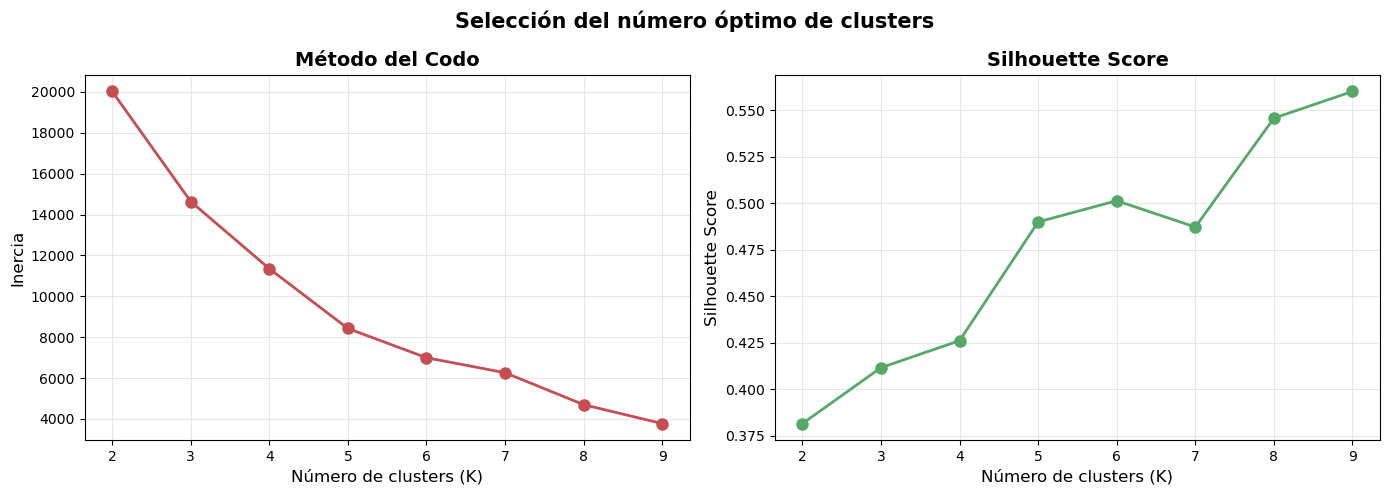

In [63]:
# Preparar features para el clustering
# Codificar variables categóricas
df_clust = top_10000_enriquecido.copy()

le = LabelEncoder()
df_clust['gender_enc']       = le.fit_transform(df_clust['gender'].astype(str))
df_clust['age_group_enc']    = le.fit_transform(df_clust['age_group'].astype(str))
df_clust['salary_group_enc'] = le.fit_transform(df_clust['salary_group'].astype(str))

# Features para clustering
features_clust = ['age_group_enc', 'salary_group_enc', 'gender_enc']
X_clust = df_clust[features_clust]

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

# Método del codo + Silhouette
inertias = []
silhouettes = []
rango_k = range(2, 10)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

print("Inercia y Silhouette por K:")
for k, ine, sil in zip(rango_k, inertias, silhouettes):
    print(f"  K={k}: Inercia={ine:,.0f} | Silhouette={sil:.3f}")

# Gráfico del codo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(rango_k), inertias, 'o-', color='#C44E52', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de clusters (K)', fontsize=12)
axes[0].set_ylabel('Inercia', fontsize=12)
axes[0].set_title('Método del Codo', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].plot(list(rango_k), silhouettes, 'o-', color='#55A868', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle('Selección del número óptimo de clusters', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [64]:
# Entrenar K-Means con 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Asignar cluster a cada cliente
df_clust['creatividad'] = kmeans.labels_ + 1  # +1 para que vaya de 1 a 5

# Perfil de cada creatividad
print("Perfil de cada creatividad:")
perfil = df_clust.groupby('creatividad').agg(
    n_clientes=('id_user', 'count'),
    edad_grupo=('age_group', lambda x: x.value_counts().index[0]),
    salario_grupo=('salary_group', lambda x: x.value_counts().index[0]),
    genero_predominante=('gender', lambda x: x.value_counts().index[0]),
).reset_index()

print(perfil)

# Distribución por creatividad
print("\nDistribución de clientes por creatividad:")
print(df_clust['creatividad'].value_counts().sort_index())

Perfil de cada creatividad:
   creatividad  n_clientes edad_grupo salario_grupo genero_predominante
0            1        1445      45-55       80-120k                   V
1            2        2570      35-45       80-120k                   H
2            3        1289      35-45         120k+                   H
3            4        2977      35-45       80-120k                   V
4            5        1719      25-35         120k+                   V

Distribución de clientes por creatividad:
creatividad
1    1445
2    2570
3    1289
4    2977
5    1719
Name: count, dtype: int64


In [65]:
# Ver distribución de variables adicionales por creatividad
print("Distribución por creatividad y lifecycle_phase:")
print(pd.crosstab(df_clust['creatividad'], df_clust['lifecycle_phase']))

print("\nDistribución por creatividad y cluster_name (Tarea 2):")
print(pd.crosstab(df_clust['creatividad'], df_clust['cluster_name']))

print("\nDistribución por creatividad y region_code:")
print(df_clust.groupby('creatividad')['region_code'].value_counts().groupby(level=0).head(3))

Distribución por creatividad y lifecycle_phase:
lifecycle_phase  Captacion  Consolidacion
creatividad                              
1                     1103            332
2                     2216            354
3                     1056            233
4                     2434            543
5                     1302            417

Distribución por creatividad y cluster_name (Tarea 2):
cluster_name  Ahorradores - deposito a largo plazo  \
creatividad                                          
1                                               35   
2                                               20   
3                                               17   
4                                               47   
5                                               48   

cluster_name  Basicos - solo cuenta easyMoney  \
creatividad                                     
1                                         125   
2                                          99   
3                          

In [66]:
# Calcular distribución porcentual
cross_pct = pd.crosstab(
    df_clust['creatividad'], 
    df_clust['cluster_name'],
    normalize='index'
).round(3) * 100

cross_abs = pd.crosstab(
    df_clust['creatividad'], 
    df_clust['cluster_name']
)

# Una tabla por creatividad
for cre in sorted(df_clust['creatividad'].unique()):
    perfil = df_clust[df_clust['creatividad'] == cre]
    
    fig = go.Figure(data=[go.Table(
        header=dict(
            values=['<b>Variable</b>', '<b>Valor predominante</b>', '<b>Detalle</b>'],
            fill_color='#2C3E50',
            font=dict(color='white', size=12),
            align='center',
            height=30
        ),
        cells=dict(
            values=[
                ['Nº Clientes', 'Edad', 'Salario', 'Género', 
                 'Lifecycle principal', 'Cluster principal', '2º Cluster'],
                [
                    f"{len(perfil):,}",
                    perfil['age_group'].value_counts().index[0],
                    perfil['salary_group'].value_counts().index[0],
                    perfil['gender'].value_counts().index[0],
                    perfil['lifecycle_phase'].value_counts().index[0],
                    perfil['cluster_name'].value_counts().index[0],
                    perfil['cluster_name'].value_counts().index[1] if len(perfil['cluster_name'].value_counts()) > 1 else '-'
                ],
                [
                    '',
                    f"{perfil['age_group'].value_counts().iloc[0]/len(perfil):.0%}",
                    f"{perfil['salary_group'].value_counts().iloc[0]/len(perfil):.0%}",
                    f"{perfil['gender'].value_counts().iloc[0]/len(perfil):.0%}",
                    f"{perfil['lifecycle_phase'].value_counts().iloc[0]/len(perfil):.0%}",
                    f"{perfil['cluster_name'].value_counts().iloc[0]/len(perfil):.0%}",
                    f"{perfil['cluster_name'].value_counts().iloc[1]/len(perfil):.0%}" if len(perfil['cluster_name'].value_counts()) > 1 else '-'
                ]
            ],
            fill_color=[['#f9f9f9', '#ffffff', '#f9f9f9', '#ffffff', '#f9f9f9', '#ffffff', '#f9f9f9']],
            font=dict(size=11),
            align='center',
            height=28
        )
    )])

    fig.update_layout(
        title=dict(
            text=f'Creatividad {cre} — Perfil de clientes',
            font=dict(size=14),
            x=0.5
        ),
        width=700,
        height=300,
        margin=dict(l=20, r=20, t=50, b=20)
    )
    fig.show()

print("✅ Tablas generadas correctamente")

✅ Tablas generadas correctamente


# 4. Asignamos creatividades

In [67]:
# Mapeo de creatividades con nombre y mensaje personalizado
creatividades = {
    1: {
        'nombre': 'Experiencia y solidez',
        'mensaje': 'Años de esfuerzo merecen una tarjeta a tu altura. Sin comisiones y con ventajas exclusivas para profesionales como tú'
    },
    2: {
        'nombre': 'Exito sin limites',
        'mensaje': 'Tu éxito profesional merece una tarjeta premium. Límites altos, beneficios exclusivos y un servicio pensado para ti'
    },
    3: {
        'nombre': 'Inteligente y practico',
        'mensaje': 'La tarjeta que se adapta a tu ritmo. Cashback en tus compras del día a día y sin comisiones'
    },
    4: {
        'nombre': 'Activo y conectado',
        'mensaje': 'Para los que no paran. Gestiona tus gastos desde el móvil y saca partido a cada compra con tu tarjeta easyMoney'
    },
    5: {
        'nombre': 'Premium y exclusivo',
        'mensaje': 'Accede a un mundo de ventajas exclusivas. Límites sin restricciones y beneficios pensados para quienes lo dan todo'
    }
}

# Añadir nombre y mensaje al dataframe
df_clust['nombre_creatividad'] = df_clust['creatividad'].map(
    {k: v['nombre'] for k, v in creatividades.items()}
)
df_clust['mensaje'] = df_clust['creatividad'].map(
    {k: v['mensaje'] for k, v in creatividades.items()}
)

# Mapeo de creatividades
print("Mapeo de creatividades:")
resumen = df_clust.groupby(['creatividad', 'nombre_creatividad']).agg(
    n_clientes=('id_user', 'count'),
    edad_predominante=('age_group', lambda x: x.value_counts().index[0]),
    salario_predominante=('salary_group', lambda x: x.value_counts().index[0]),
    genero_predominante=('gender', lambda x: x.value_counts().index[0])
).reset_index()
print(resumen)

Mapeo de creatividades:
   creatividad      nombre_creatividad  n_clientes edad_predominante  \
0            1   Experiencia y solidez        1445             45-55   
1            2       Exito sin limites        2570             35-45   
2            3  Inteligente y practico        1289             35-45   
3            4      Activo y conectado        2977             35-45   
4            5     Premium y exclusivo        1719             25-35   

  salario_predominante genero_predominante  
0              80-120k                   V  
1              80-120k                   H  
2                120k+                   H  
3              80-120k                   V  
4                120k+                   V  


In [68]:
# Sustituir V y H por términos más claros
resumen_visual = resumen.copy()
resumen_visual['genero_predominante'] = resumen_visual['genero_predominante'].map({
    'V': 'Varón',
    'H': 'Mujer'
})

fig = go.Figure(data=[go.Table(
    header=dict(
        values=[
            '<b>Creatividad</b>',
            '<b>Nombre</b>',
            '<b>Nº Clientes</b>',
            '<b>Edad predominante</b>',
            '<b>Salario predominante</b>',
            '<b>Género predominante</b>'
        ],
        fill_color='#2C3E50',
        font=dict(color='white', size=12),
        align='center',
        height=35
    ),
    cells=dict(
        values=[
            resumen_visual['creatividad'],
            resumen_visual['nombre_creatividad'],
            resumen_visual['n_clientes'].apply(lambda x: f'{x:,}'),
            resumen_visual['edad_predominante'],
            resumen_visual['salario_predominante'],
            resumen_visual['genero_predominante']
        ],
        fill_color=[
            ['#f9f9f9', '#ffffff', '#f9f9f9', '#ffffff', '#f9f9f9'],
        ],
        font=dict(size=11),
        align='center',
        height=30
    )
)])

fig.update_layout(
    title=dict(
        text='Resumen de Creatividades — Campaña Credit Card',
        font=dict(size=15),
        x=0.5
    ),
    width=900,
    height=300,
    margin=dict(l=20, r=20, t=60, b=20)
)

fig.show()

print("Tabla generada correctamente")

Tabla generada correctamente


# 5. Generar fichero para CSV para Frank

In [69]:
# Generar CSV final para Frank
csv_frank_personalizado = df_clust[[
    'id_user', 
    'segment', 
    'creatividad', 
    'nombre_creatividad',
    'mensaje'
]].rename(columns={
    'creatividad': 'creatividad_id'
})

# Fichero completo
csv_frank_personalizado.to_csv('recomendacion_10000_personalizado.csv', index=False)

# Muestra de 1.000 para prueba
csv_frank_personalizado.sample(1000, random_state=42).to_csv(
    'muestra_1000_personalizado.csv', index=False
)

print(f"\n✅ Ficheros generados correctamente")
print(f"\nMuestra:")
print(csv_frank_personalizado.head(10))


✅ Ficheros generados correctamente

Muestra:
   id_user      segment  creatividad_id     nombre_creatividad  \
0  1070525  credit_card               1  Experiencia y solidez   
1  1114367  credit_card               5    Premium y exclusivo   
2  1437442  credit_card               1  Experiencia y solidez   
3  1297310  credit_card               2      Exito sin limites   
4  1311558  credit_card               4     Activo y conectado   
5   215466  credit_card               5    Premium y exclusivo   
6  1008275  credit_card               4     Activo y conectado   
7  1104802  credit_card               2      Exito sin limites   
8  1121475  credit_card               5    Premium y exclusivo   
9  1122628  credit_card               5    Premium y exclusivo   

                                             mensaje  
0  Años de esfuerzo merecen una tarjeta a tu altu...  
1  Accede a un mundo de ventajas exclusivas. Lími...  
2  Años de esfuerzo merecen una tarjeta a tu altu...  
3  Tu é

# 6. Algunos gráficos interesantes

## 5.1 Distribución de clientes por creatividad

In [70]:
fig1 = px.pie(
    resumen_visual,
    values='n_clientes',
    names='nombre_creatividad',
    title='Distribución de clientes por creatividad',
    color_discrete_sequence=[
    'rgb(142, 68, 173)',   # Morado
    'rgb(231, 76, 60)',    # Rojo
    'rgb(52, 152, 219)',   # Azul claro
    'rgb(46, 204, 113)',   # Verde
    'rgb(243, 156, 18)'    # Naranja
    ],
    hole=0.45
)

fig1.update_traces(
    textposition='outside',
    textinfo='percent+label',
    textfont=dict(size=12),
    pull=[0.03, 0.03, 0.03, 0.03, 0.03],
    marker=dict(line=dict(color='white', width=2))
)

fig1.update_layout(
    title=dict(
        text='Distribución de clientes por creatividad',
        font=dict(size=18, color='rgb(44, 62, 80)'),
        x=0.5
    ),
    legend=dict(
        orientation='v',
        yanchor='middle',
        y=0.5,
        xanchor='left',
        x=1.05,
        font=dict(size=12)
    ),
    annotations=[dict(
        text='10.000<br>clientes',
        x=0.5, y=0.5,
        font=dict(size=14, color='rgb(44, 62, 80)'),
        showarrow=False
    )],
    width=800,
    height=500,
    margin=dict(l=20, r=150, t=80, b=20),
    paper_bgcolor='white',
    plot_bgcolor='white'
)

fig1.show()

## 5.2 Distribucion por edad y creatividad

In [71]:
# ── 2. Distribución por edad y creatividad ───────────────────
edad_creat = pd.crosstab(
    df_clust['nombre_creatividad'],
    df_clust['age_group'],
    normalize='index'
).reset_index()

# Multiplicar solo las columnas numéricas por 100
cols_numericas = [c for c in edad_creat.columns if c != 'nombre_creatividad']
edad_creat[cols_numericas] = edad_creat[cols_numericas] * 100

edad_creat_melt = edad_creat.melt(
    id_vars='nombre_creatividad',
    var_name='age_group',
    value_name='porcentaje'
)

fig2 = px.bar(
    edad_creat_melt,
    x='nombre_creatividad',
    y='porcentaje',
    color='age_group',
    title='Distribución de edad por creatividad',
    labels={
        'nombre_creatividad': 'Creatividad', 
        'porcentaje': '%', 
        'age_group': 'Grupo de edad'
    },
    color_discrete_sequence=[
    '#8E44AD',   # Morado
    '#E74C3C',   # Rojo
    '#3498DB',   # Azul claro
    '#2ECC71',   # Verde
    '#F39C12',   # Naranja
    '#B7950B'    # Amarillo mostaza
],
    barmode='stack'
)

fig2.update_layout(
    title=dict(x=0.5, font=dict(size=15)),
    xaxis_tickangle=-15,
    width=900, 
    height=500,
    template='plotly_white'
)

fig2.show()

## 5.3 Distribución de salario por creatividad

In [72]:
# ── 3. Distribución por salario y creatividad ────────────────
salario_creat = pd.crosstab(
    df_clust['nombre_creatividad'],
    df_clust['salary_group'],
    normalize='index'
).reset_index()

# Multiplicar solo las columnas numéricas por 100
cols_numericas = [c for c in salario_creat.columns if c != 'nombre_creatividad']
salario_creat[cols_numericas] = salario_creat[cols_numericas] * 100

salario_creat_melt = salario_creat.melt(
    id_vars='nombre_creatividad',
    var_name='salary_group',
    value_name='porcentaje'
)

fig3 = px.bar(
    salario_creat_melt,
    x='nombre_creatividad',
    y='porcentaje',
    color='salary_group',
    title='Distribución de salario por creatividad',
    labels={
        'nombre_creatividad': 'Creatividad', 
        'porcentaje': '%', 
        'salary_group': 'Grupo salarial'
    },
    color_discrete_sequence=[
        '#8E44AD',   # Morado
        '#E74C3C',   # Rojo
        '#3498DB',   # Azul claro
        '#2ECC71',   # Verde
        '#F39C12',   # Naranja
        '#B7950B'    # Amarillo mostaza
    ],
    barmode='stack',
    category_orders={
        'salary_group': ['<20k', '20-40k', '40-60k', '60-80k', '80-120k', '120k+']
    }
)

fig3.update_layout(
    title=dict(x=0.5, font=dict(size=15)),
    xaxis_tickangle=-15,
    width=900, 
    height=500,
    template='plotly_white'
)

fig3.show()

## 5.4 Distribución por genero y creatividad

In [73]:
# ── 4. Distribución por género y creatividad ─────────────────
genero_creat = pd.crosstab(
    df_clust['nombre_creatividad'],
    df_clust['gender'],
    normalize='index'
).reset_index()

# Multiplicar solo las columnas numéricas por 100
cols_numericas = [c for c in genero_creat.columns if c != 'nombre_creatividad']
genero_creat[cols_numericas] = genero_creat[cols_numericas] * 100

genero_creat_melt = genero_creat.melt(
    id_vars='nombre_creatividad',
    var_name='gender',
    value_name='porcentaje'
)

# Mapear V/H a Varón/Mujer
genero_creat_melt['gender'] = genero_creat_melt['gender'].map({
    'V': 'Varón', 
    'H': 'Mujer'
})

fig4 = px.bar(
    genero_creat_melt,
    x='nombre_creatividad',
    y='porcentaje',
    color='gender',
    title='Distribución de género por creatividad',
    labels={
        'nombre_creatividad': 'Creatividad', 
        'porcentaje': '%', 
        'gender': 'Género'
    },
    color_discrete_map={
        'Varón': '#3498DB', 
        'Mujer': '#8E44AD'
    },
    barmode='stack',
    category_orders={
        'gender': ['Varón', 'Mujer']
    }
)

fig4.update_layout(
    title=dict(x=0.5, font=dict(size=15)),
    xaxis_tickangle=-15,
    width=900, 
    height=500,
    template='plotly_white'
)

fig4.show()

## 5.5 Distribución por lifecycle y creatividad

In [74]:
# ── 5. Distribución por lifecycle y creatividad ──────────────
lifecycle_creat = pd.crosstab(
    df_clust['nombre_creatividad'],
    df_clust['lifecycle_phase'],
    normalize='index'
).reset_index()

# Multiplicar solo las columnas numéricas por 100
cols_numericas = [c for c in lifecycle_creat.columns if c != 'nombre_creatividad']
lifecycle_creat[cols_numericas] = lifecycle_creat[cols_numericas] * 100

lifecycle_creat_melt = lifecycle_creat.melt(
    id_vars='nombre_creatividad',
    var_name='lifecycle_phase',
    value_name='porcentaje'
)

fig5 = px.bar(
    lifecycle_creat_melt,
    x='nombre_creatividad',
    y='porcentaje',
    color='lifecycle_phase',
    title='Distribución por fase del ciclo de vida por creatividad',
    labels={
        'nombre_creatividad': 'Creatividad', 
        'porcentaje': '%', 
        'lifecycle_phase': 'Fase'
    },
    color_discrete_sequence=[
        '#8E44AD',   # Morado
        '#E74C3C',   # Rojo
        '#3498DB',   # Azul claro
        '#2ECC71',   # Verde
        '#F39C12',   # Naranja
        '#B7950B'    # Amarillo mostaza
    ],
    barmode='stack',
    category_orders={
        'lifecycle_phase': ['Captacion', 'Consolidacion', 'Abandono']
    }
)

fig5.update_layout(
    title=dict(x=0.5, font=dict(size=15)),
    xaxis_tickangle=-15,
    width=900, 
    height=500,
    template='plotly_white'
)

fig5.show()